In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
df = pd.read_csv("titanic.csv")
df

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0
...,...,...,...,...
886,NaN,211536,3,0
887,B42,112053,3,1
888,NaN,W./C. 6607,1,0
889,C148,111369,2,1


In [55]:
df['number'].unique()

<StringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

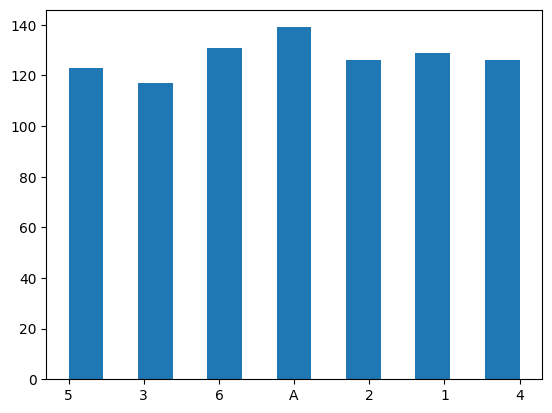

In [56]:
plt.hist(df['number'],bins=13)
plt.show()

Text(0.5, 1.0, 'Companions')

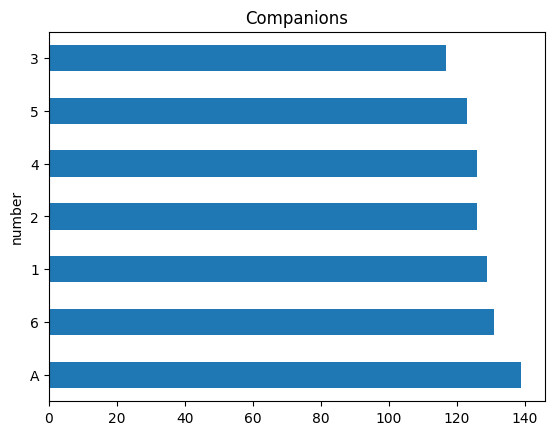

In [57]:
fig = df['number'].value_counts().plot.barh()
fig.set_title("Companions")

### Extract numerical part

In [58]:
# df['number-num'] = pd.to_numeric(df['number'],errors='raise',downcast='integer')
df['number-num'] = pd.to_numeric(df['number'],errors='coerce',downcast='integer')
df

,Cabin,Ticket,number,Survived,number-num
0,NaN,A/5 21171,5,0,5.0
1,C85,PC 17599,3,1,3.0
2,NaN,STON/O2. 3101282,6,1,6.0
3,C123,113803,3,1,3.0
4,NaN,373450,A,0,NaN
...,...,...,...,...,...
886,NaN,211536,3,0,3.0
887,B42,112053,3,1,3.0
888,NaN,W./C. 6607,1,0,1.0
889,C148,111369,2,1,2.0


### Extracting number cat

In [59]:
# np.where(condition, value_if_true, value_if_false)
df['number-cat'] = np.where(
    df['number-num'].isnull(),
    df['number'],
    np.nan
)
df.head()

,Cabin,Ticket,number,Survived,number-num,number-cat
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [60]:
df['Cabin'].nunique()

147

In [61]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [62]:
# Extracting numeric part 
df['Cabin-num'] = df['Cabin'].str.extract('(\d+)')
# Extracting categorical part 
# df['Cabin-letter'] = df['Cabin'].str.extract('([A-Za-z])')
df['Cabin-cat'] = df['Cabin'].str[0]
df

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Garv\AppData\Local\Temp\ipykernel_24936\1359135395.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Cabin-num'] = df['Cabin'].str.extract('(\d+)')


,Cabin,Ticket,number,Survived,number-num,number-cat,Cabin-num,Cabin-cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN
...,...,...,...,...,...,...,...,...
886,NaN,211536,3,0,3.0,NaN,NaN,NaN
887,B42,112053,3,1,3.0,NaN,42,B
888,NaN,W./C. 6607,1,0,1.0,NaN,NaN,NaN
889,C148,111369,2,1,2.0,NaN,148,C


<Axes: xlabel='Cabin-cat'>

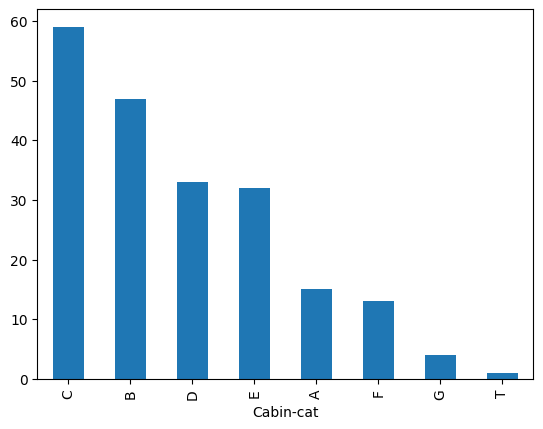

In [63]:
# df['Cabin-cat'].value_counts().plot.bar()
df['Cabin-cat'].value_counts().plot(kind='bar')

In [67]:
# Numerical data
df['ticket-num'] = df['Ticket'].apply(lambda s : s.split()[-1])
df['ticket-num'] = pd.to_numeric(df['ticket-num'],
                                 errors='coerce',
                                 downcast='integer')

# Categorical data
df['ticket-cat'] = df['Ticket'].apply(lambda s : s.split()[0])
df['ticket-cat'] = np.where(df['ticket-cat'].str.isdigit(),
                            np.nan,
                            df['ticket-cat'])

# s = pd.Series(['123', 'ABC', '456'])
# s.str.isdigit() --> s.apply(lambda x: x.isdigit())
df

,Cabin,Ticket,number,Survived,number-num,number-cat,Cabin-num,Cabin-cat,ticket-num,ticket-cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
...,...,...,...,...,...,...,...,...,...,...
886,NaN,211536,3,0,3.0,NaN,NaN,NaN,211536.0,NaN
887,B42,112053,3,1,3.0,NaN,42,B,112053.0,NaN
888,NaN,W./C. 6607,1,0,1.0,NaN,NaN,NaN,6607.0,W./C.
889,C148,111369,2,1,2.0,NaN,148,C,111369.0,NaN
